# 🧬 CHITIN
### Causal Heuristics Isolating Transcriptomic Intervention Noise

**Objective:** Strip systematic pan-perturbation variation from metacell expression matrices via localized manifold subtraction, producing a pure Δ-matrix of causal perturbation signatures for downstream GRN inference.

**Input:** SPORE Phase 8 metacell `.h5ad` files (train/val/test)  
**Output:** Δ-transformed `.h5ad` files where each perturbed metacell's expression = $x_i - \vec{N}_i$ (localized control baseline)  
**Downstream:** GuanLab PSGRN (LightGBM) → FUNGI → SPECTRA  

---

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')

from src.utils import load_config, setup_logger, apply_chitin_style
from src.utils import log_memory, snapshot, force_gc
from src import engine
from src import diagnostics as diag
from src import plotting as cplt

cfg = load_config('chitin_config.yaml')
logger = setup_logger(cfg)
apply_chitin_style(cfg)

print(f"CHITIN initialized")
print(f"  Input dir : {cfg['paths']['_input']}")
print(f"  k         : {cfg['knn']['k']}")
print(f"  n_PCs     : {cfg['knn']['n_pcs']}")
log_memory(logger, 'startup')

11:33:26 │ INFO    │ CHITIN log initialized → /scratch/patrick.sheehan/MYCELIUM/CHITIN/logs/chitin_run_20260406_113326.log
11:33:26 │ INFO    │   💾 Memory (startup): 812 MB


CHITIN initialized
  Input dir : /scratch/patrick.sheehan/MYCELIUM/CHITIN/../SPORE_heavy/processed
  k         : 20
  n_PCs     : 50


## Load SPORE Metacell Data

Loading the Phase 8 metacell-aggregated train split.  
Val and test splits will be transformed using the **same PCA space** derived from train.

In [2]:
# Load training metacells
train_path = cfg['paths']['_input'] / cfg['paths']['train_file']
adata_train = sc.read_h5ad(train_path)
snapshot(adata_train, 'Train metacells loaded', logger)

# Quick inspection
print(f"\n.obs columns: {list(adata_train.obs.columns)}")
print(f"Perturbation column ('{cfg['dataset']['perturbation_col']}'):")
print(adata_train.obs[cfg['dataset']['perturbation_col']].value_counts().head(10))

11:33:30 │ INFO    │   [Train metacells loaded] → 150,293 metacells  ×  5,000 genes  |  RAM: 3.9 GB



.obs columns: ['gene', 'n_cells_in_metacell']
Perturbation column ('gene'):
gene
non-targeting    7491
RPL3              196
PINK1             174
DUSP9             135
RAP1GAP           127
STK38L            116
ANAPC15           109
PPP2R1A           106
ESPN              100
FAM156B           100
Name: count, dtype: int64


---
## Pre-CHITIN Diagnostics

*Quantify the systematic variation BEFORE applying localized subtraction.  
This establishes the baseline that CHITIN needs to eliminate.*

### Dynamic Latent Space (Fresh PCA on Metacells)

We compute a **fresh PCA** directly on the metacell data — NOT inherited from SPORE.  
The Phase 8 aggregation fundamentally altered the topological geometry.

In [3]:
# Instantiate the CHITIN model and fit the training reference manifold
# This automatically computes the fresh PCA and fits the KNN on control metacells
chitin_model = engine.ChitinModel()
adata_train = chitin_model.fit(adata_train, cfg, logger)

11:33:35 │ INFO    │ ════════════════════════════════════════════════════════════
11:33:35 │ INFO    │   CHITIN · Fitting Reference Manifold (Train Controls)
11:33:35 │ INFO    │ ════════════════════════════════════════════════════════════
11:33:35 │ INFO    │   Computing PCA on training data (50 components, randomized)...
11:33:45 │ INFO    │   🗑️  GC collected 13 objects  |  RAM: 4.3 GB
11:33:45 │ INFO    │   Control metacells in training split: 7,491
11:33:45 │ INFO    │   Fitting KNN (k=20, metric='euclidean') on 7,491 controls...
11:33:46 │ INFO    │   CHITIN model fitted. Ready to transform any split.
11:33:46 │ INFO    │   💾 Memory (post fit): 4.4 GB


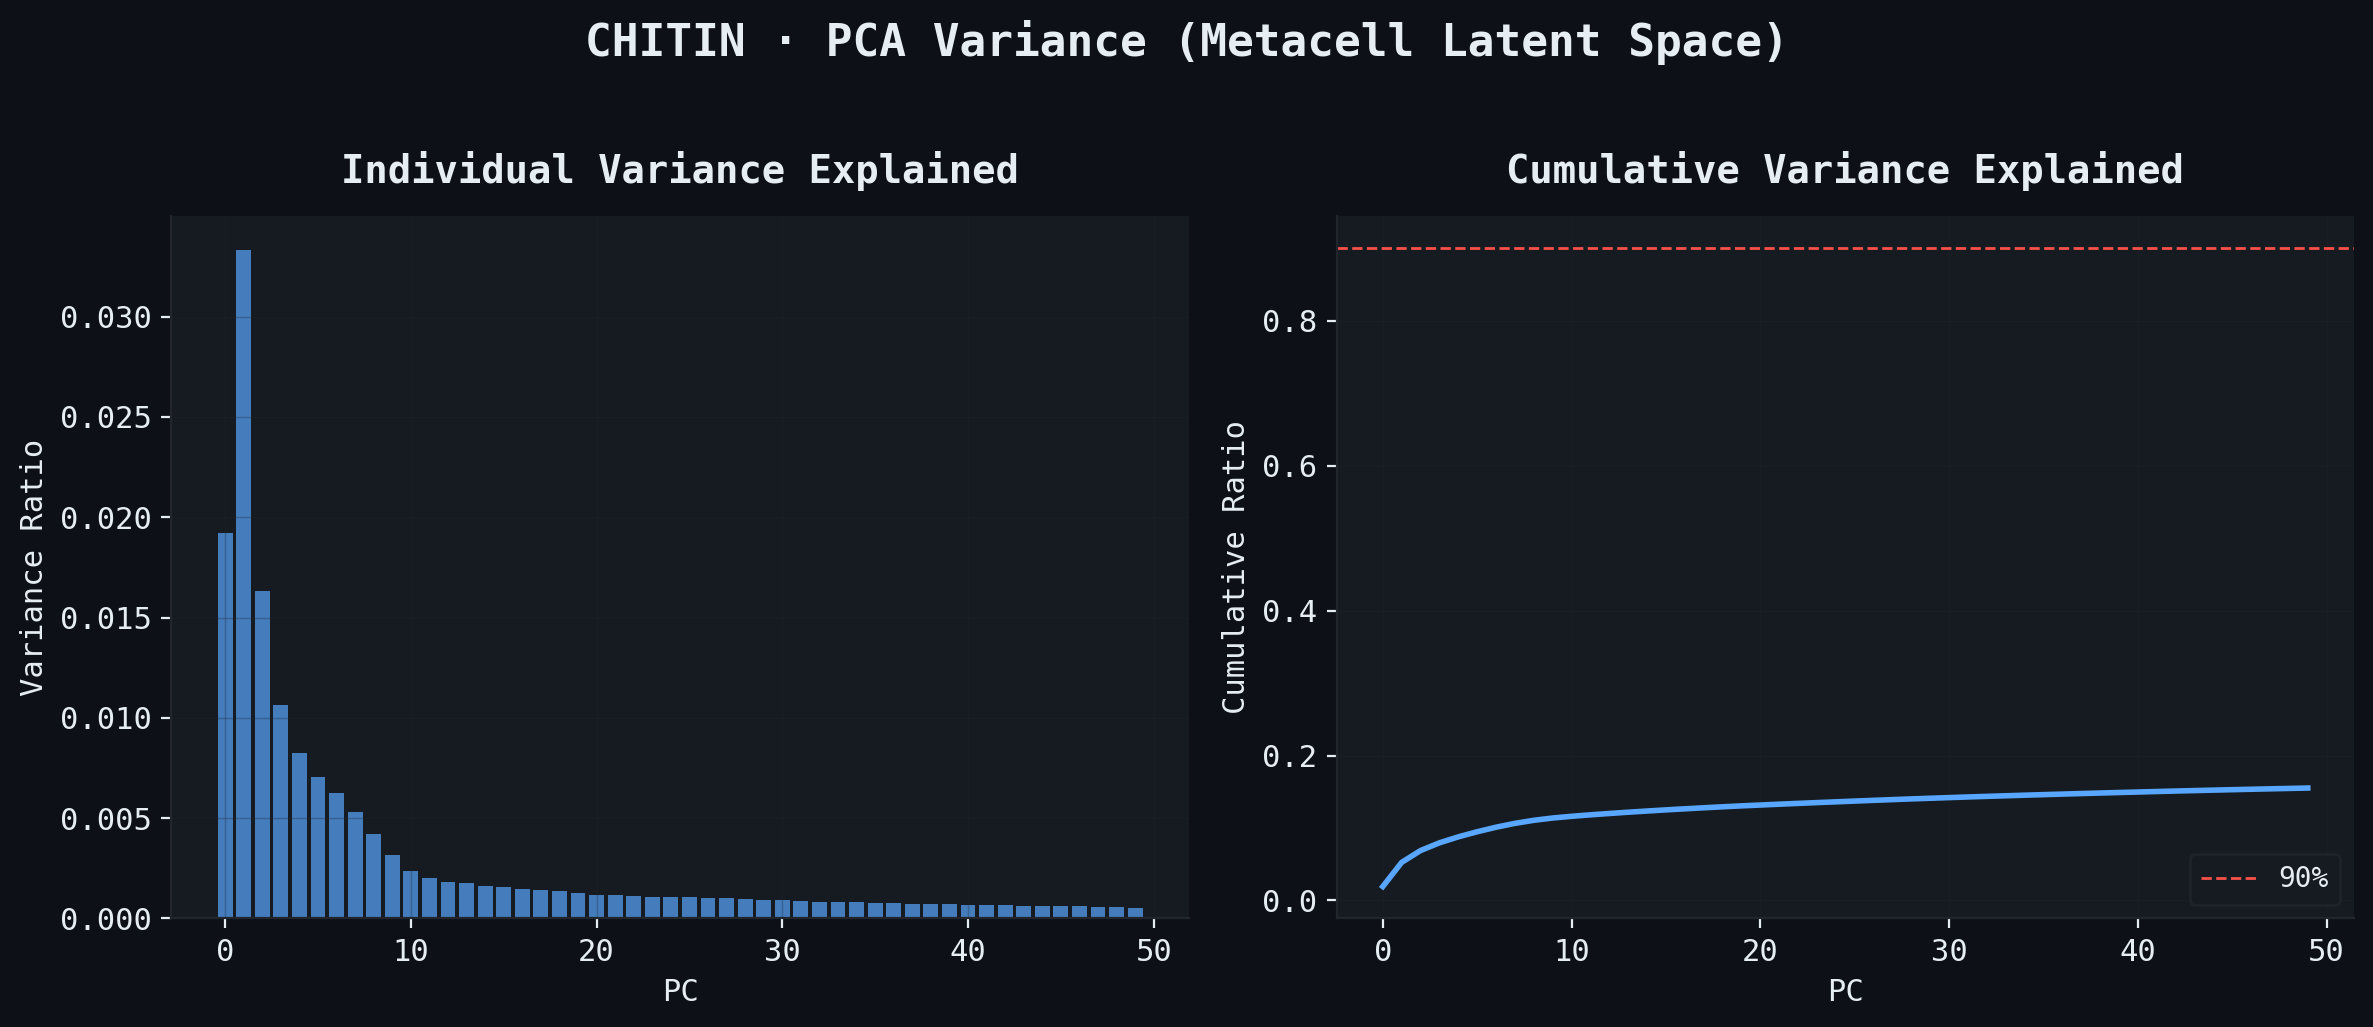

In [4]:
# PCA variance explained
cplt.plot_pca_variance(adata_train, cfg)

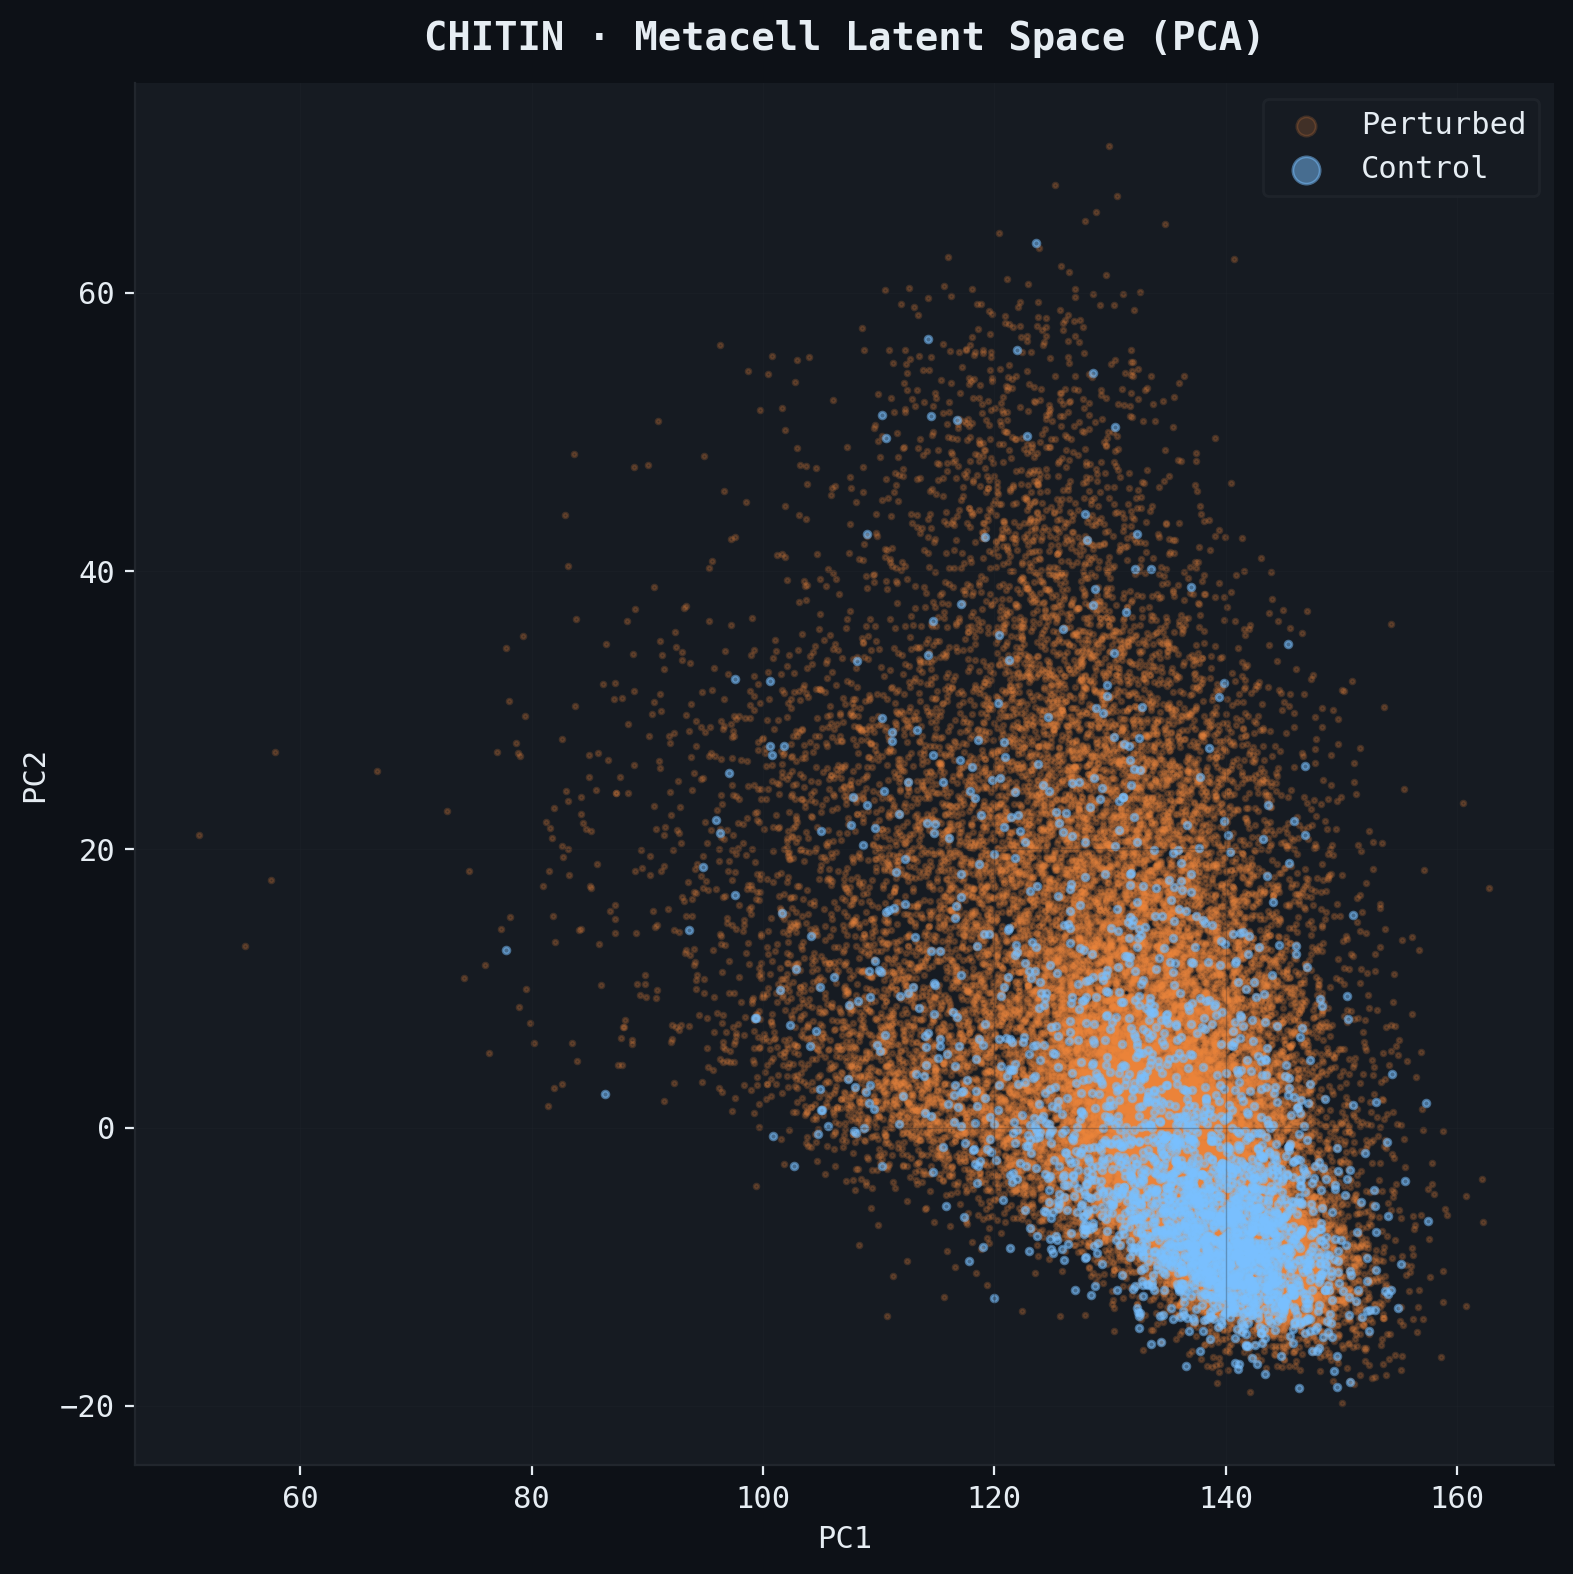

In [5]:
# Latent space visualization (PC1 vs PC2)
cplt.plot_latent_space(adata_train, cfg)

### Systema Centroid Analysis (Pre-CHITIN)

Compute $C_{ctrl}$, $O_{pert}$, and the systematic variation vector $\vec{V}$.  
Measure cosine similarity between perturbation-specific shifts and $\vec{V}$.  

⚠️ These centroids are for **evaluation only** — they are NOT used in the CHITIN transformation.

In [6]:
# Compute Systema centroids on pre-CHITIN data
C_ctrl_pre, O_pert_pre, V_pre = diag.compute_systema_centroids(
    adata_train, cfg, logger)

# Compute per-perturbation cosine similarities
cos_ctrl_pre, cos_pert_pre, pert_names = diag.compute_perturbation_cosines(
    adata_train, C_ctrl_pre, O_pert_pre, cfg, logger)

11:35:26 │ INFO    │   Systema centroids computed:
11:35:26 │ INFO    │     C_ctrl norm: 111.0663
11:35:26 │ INFO    │     O_pert norm: 110.1566
11:35:26 │ INFO    │     |V| (systematic variation magnitude): 2.8333
11:35:29 │ INFO    │   Cosine similarities (control ref): mean=0.244 ± 0.172
11:35:29 │ INFO    │   Cosine similarities (perturbed ref): mean=-0.021 ± 0.199


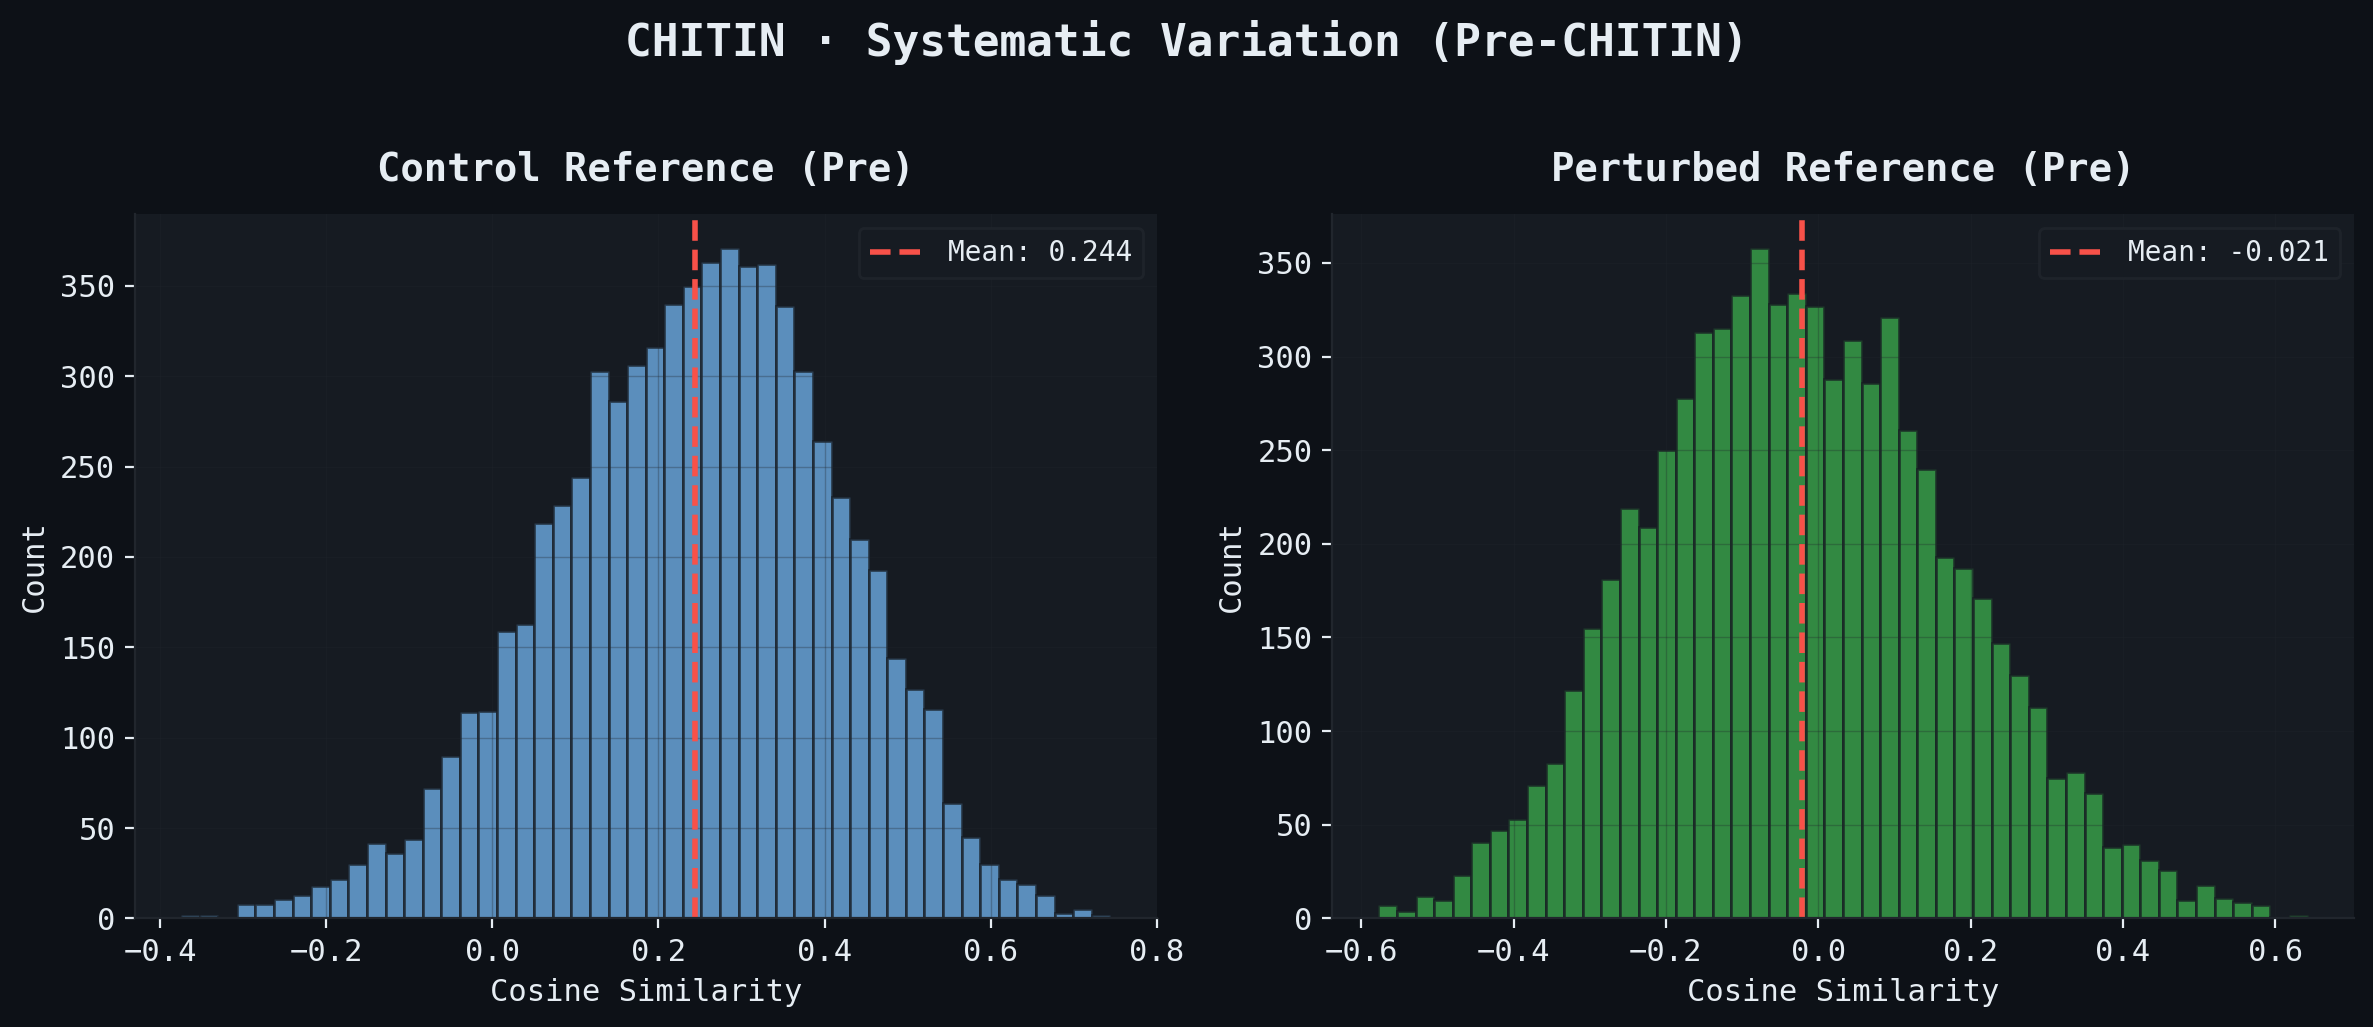

In [7]:
# Cosine distributions (pre-CHITIN)
cplt.plot_cosine_distributions(cos_ctrl_pre, cos_pert_pre, cfg, label='pre')

### k-Sensitivity Analysis

Sweep across k values to verify that the chosen k produces **localized** neighborhoods  
rather than collapsing toward the global control mean.

- **High basal variance** → neighborhoods are diverse (good, localized)
- **Low basal variance** → neighborhoods converge to global mean (bad, rank-order invariance returns)

11:35:51 │ INFO    │ ════════════════════════════════════════════════════════════
11:35:51 │ INFO    │   CHITIN · k-Sensitivity Sweep
11:35:51 │ INFO    │ ════════════════════════════════════════════════════════════
11:35:52 │ INFO    │   k=   5 → basal variance: 0.072592, mean dist: 14.6406
11:35:52 │ INFO    │   k=  10 → basal variance: 0.059751, mean dist: 15.4814
11:35:53 │ INFO    │   k=  15 → basal variance: 0.054053, mean dist: 16.0450
11:35:53 │ INFO    │   k=  20 → basal variance: 0.050569, mean dist: 16.4784
11:35:54 │ INFO    │   k=  30 → basal variance: 0.046027, mean dist: 17.1336
11:35:55 │ INFO    │   k=  50 → basal variance: 0.040753, mean dist: 18.0380
11:35:56 │ INFO    │   k=  75 → basal variance: 0.036766, mean dist: 18.8221
11:35:58 │ INFO    │   k= 100 → basal variance: 0.033958, mean dist: 19.4187


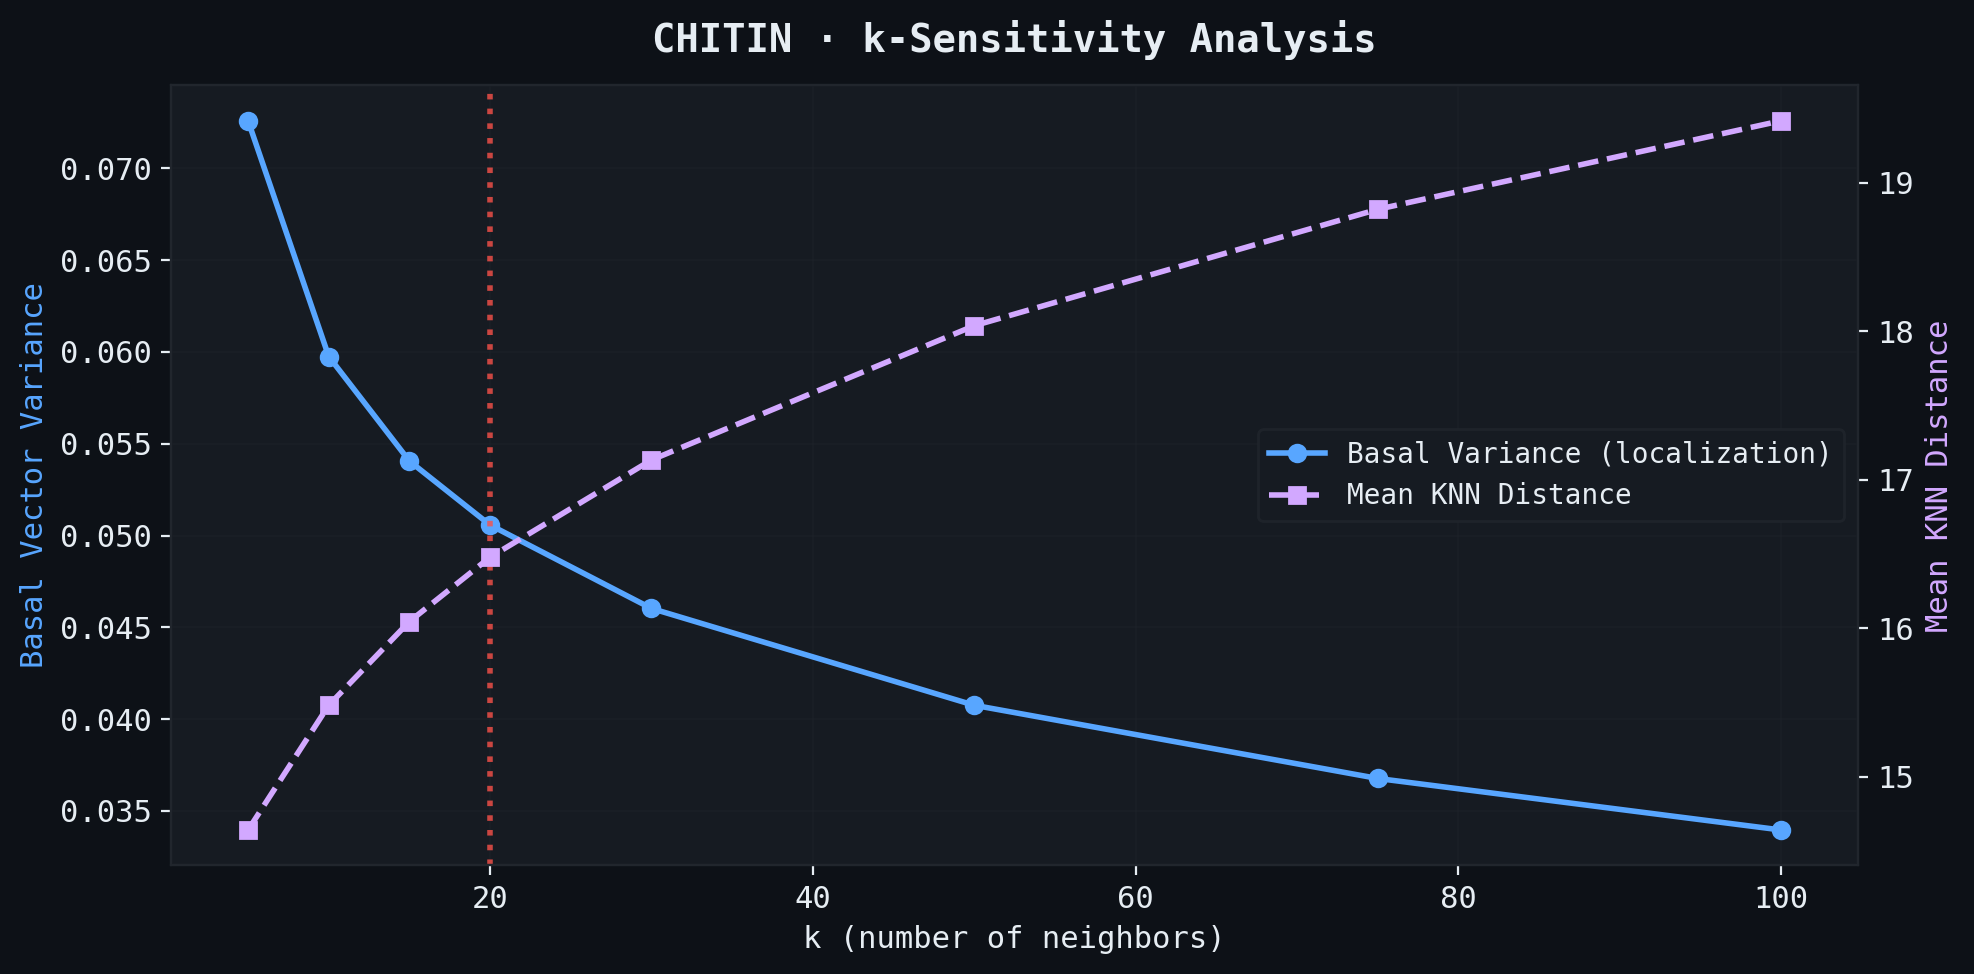

In [8]:
if cfg['diagnostics']['k_sweep']:
    k_vals, basal_vars, mean_dists = diag.k_sensitivity_sweep(
        adata_train, cfg, logger)
    cplt.plot_k_sensitivity(k_vals, basal_vars, mean_dists,
                            chosen_k=cfg['knn']['k'], cfg=cfg)

---
## CHITIN Transformation (Train Split)

**The core operation:** For each perturbed metacell $x_i$:
1. Find its $k$ nearest **control** neighbors in the fresh PCA latent space
2. Compute the localized basal vector $\vec{N}_i$ = mean of those neighbors
3. Extract the causal delta: $\Delta X_i = x_i - \vec{N}_i$

Control metacells are set to $\Delta = 0$ (they ARE the baseline).

In [9]:
# Extract the causal delta for the training split using the fitted model
adata_train_delta = chitin_model.transform(adata_train, cfg, logger, label="Train")

11:36:34 │ INFO    │ ════════════════════════════════════════════════════════════
11:36:34 │ INFO    │   CHITIN · Transforming [Train]
11:36:34 │ INFO    │ ════════════════════════════════════════════════════════════
11:36:34 │ INFO    │   [Train] Controls in this split: 7,491 | Perturbed: 142,802
11:36:34 │ INFO    │   Projecting into training PCA space...
11:36:37 │ INFO    │   [Train] KNN complete → 142,802 × 20 neighbors
11:36:50 │ INFO    │   [Post CHITIN [Train]] → 150,293 metacells  ×  5,000 genes  |  RAM: 22.2 GB


---
## Post-CHITIN Diagnostics

*Verify that systematic variation has been reduced.*

11:39:07 │ INFO    │ ════════════════════════════════════════════════════════════
11:39:07 │ INFO    │   CHITIN · Rank-Order Disruption Analysis
11:39:07 │ INFO    │ ════════════════════════════════════════════════════════════
11:39:11 │ INFO    │   Rank-order disruption (200 genes sampled):
11:39:11 │ INFO    │     Mean Spearman correlation: 0.9267
11:39:11 │ INFO    │     Std:  0.0671
11:39:11 │ INFO    │     Min:  0.1332
11:39:11 │ INFO    │     Max:  0.9785
11:39:11 │ INFO    │     Moderate rank disruption — partial reshaping of the information gain landscape


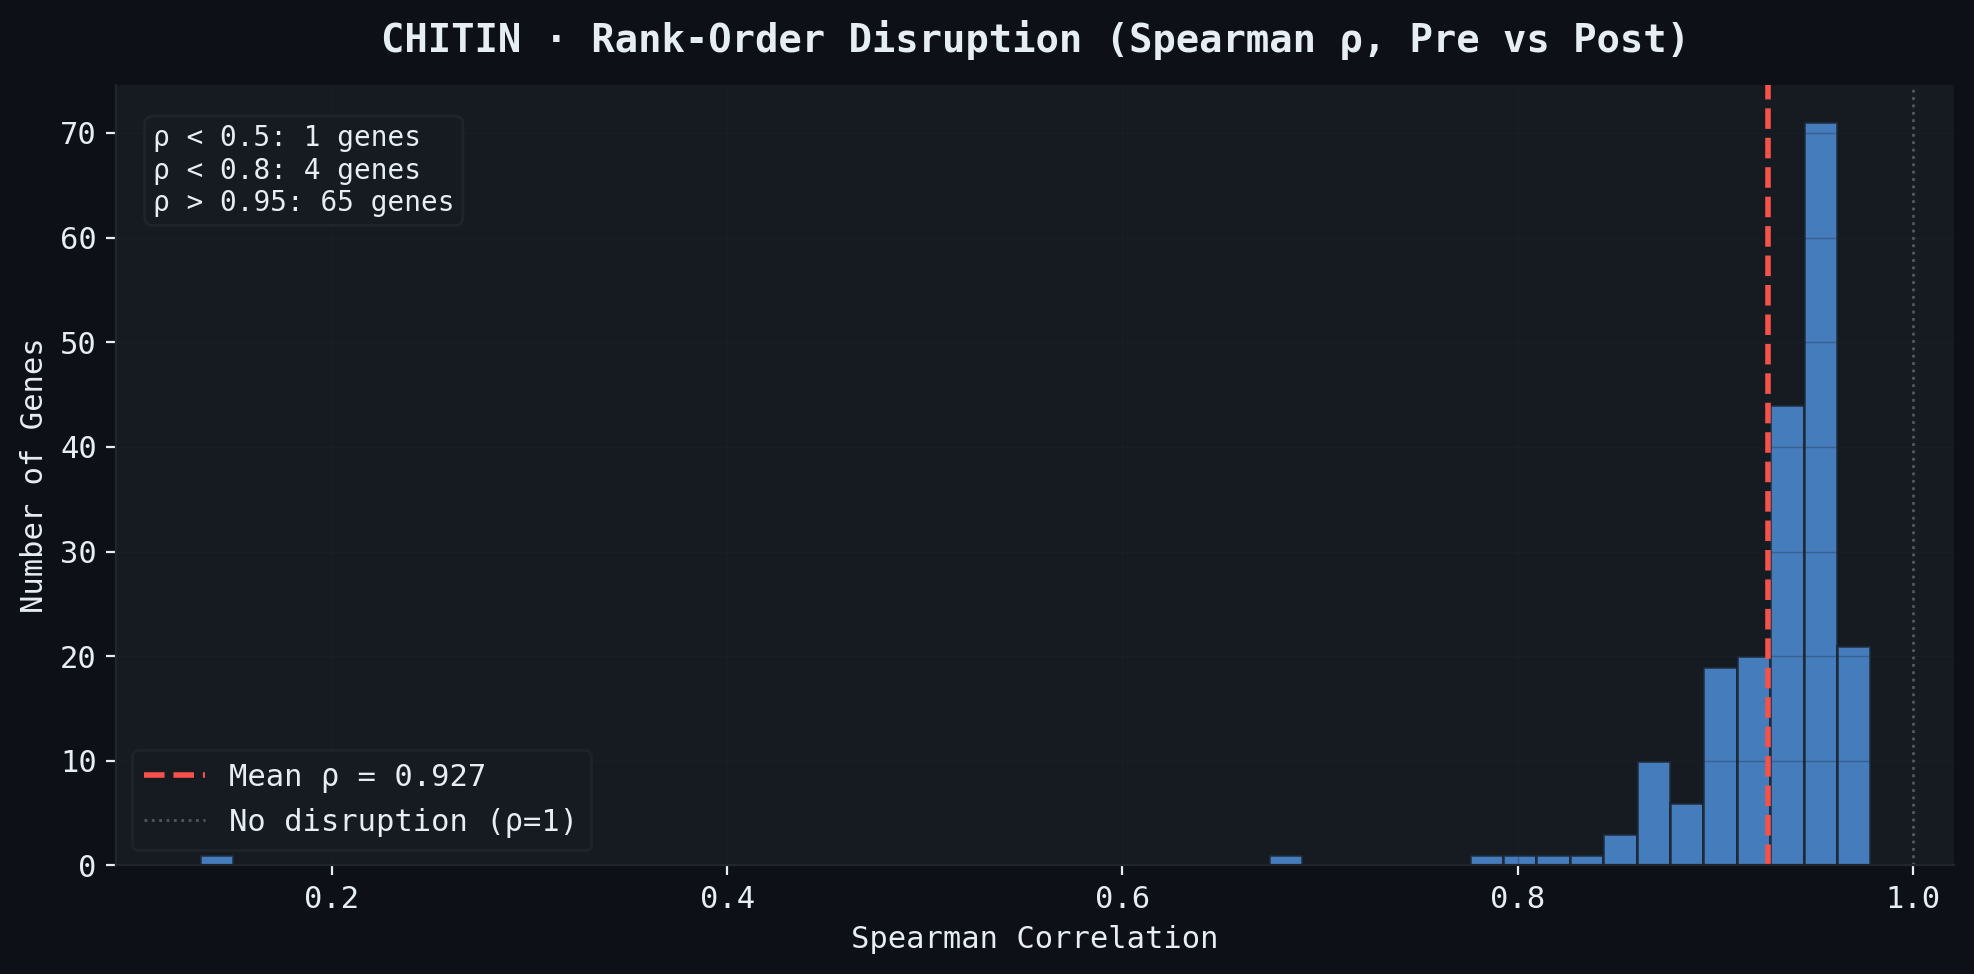

In [11]:
# ── Rank-Order Disruption (the metric that actually matters for LightGBM) ──
mean_rho, rank_corrs, sampled_genes = diag.compute_rank_disruption(
    adata_train, adata_train_delta, cfg, logger)
cplt.plot_rank_disruption(rank_corrs, sampled_genes, cfg)

11:39:56 │ INFO    │   Pairwise perturbation discrimination (5000 pairs):
11:39:56 │ INFO    │     Pre-CHITIN  → mean cosine dist: 0.0103 ± 0.0050
11:39:56 │ INFO    │     Post-CHITIN → mean cosine dist: 0.2287 ± 0.0749
11:39:56 │ INFO    │     ✓ Discrimination improved by 2113.4% (perturbations are more separable)


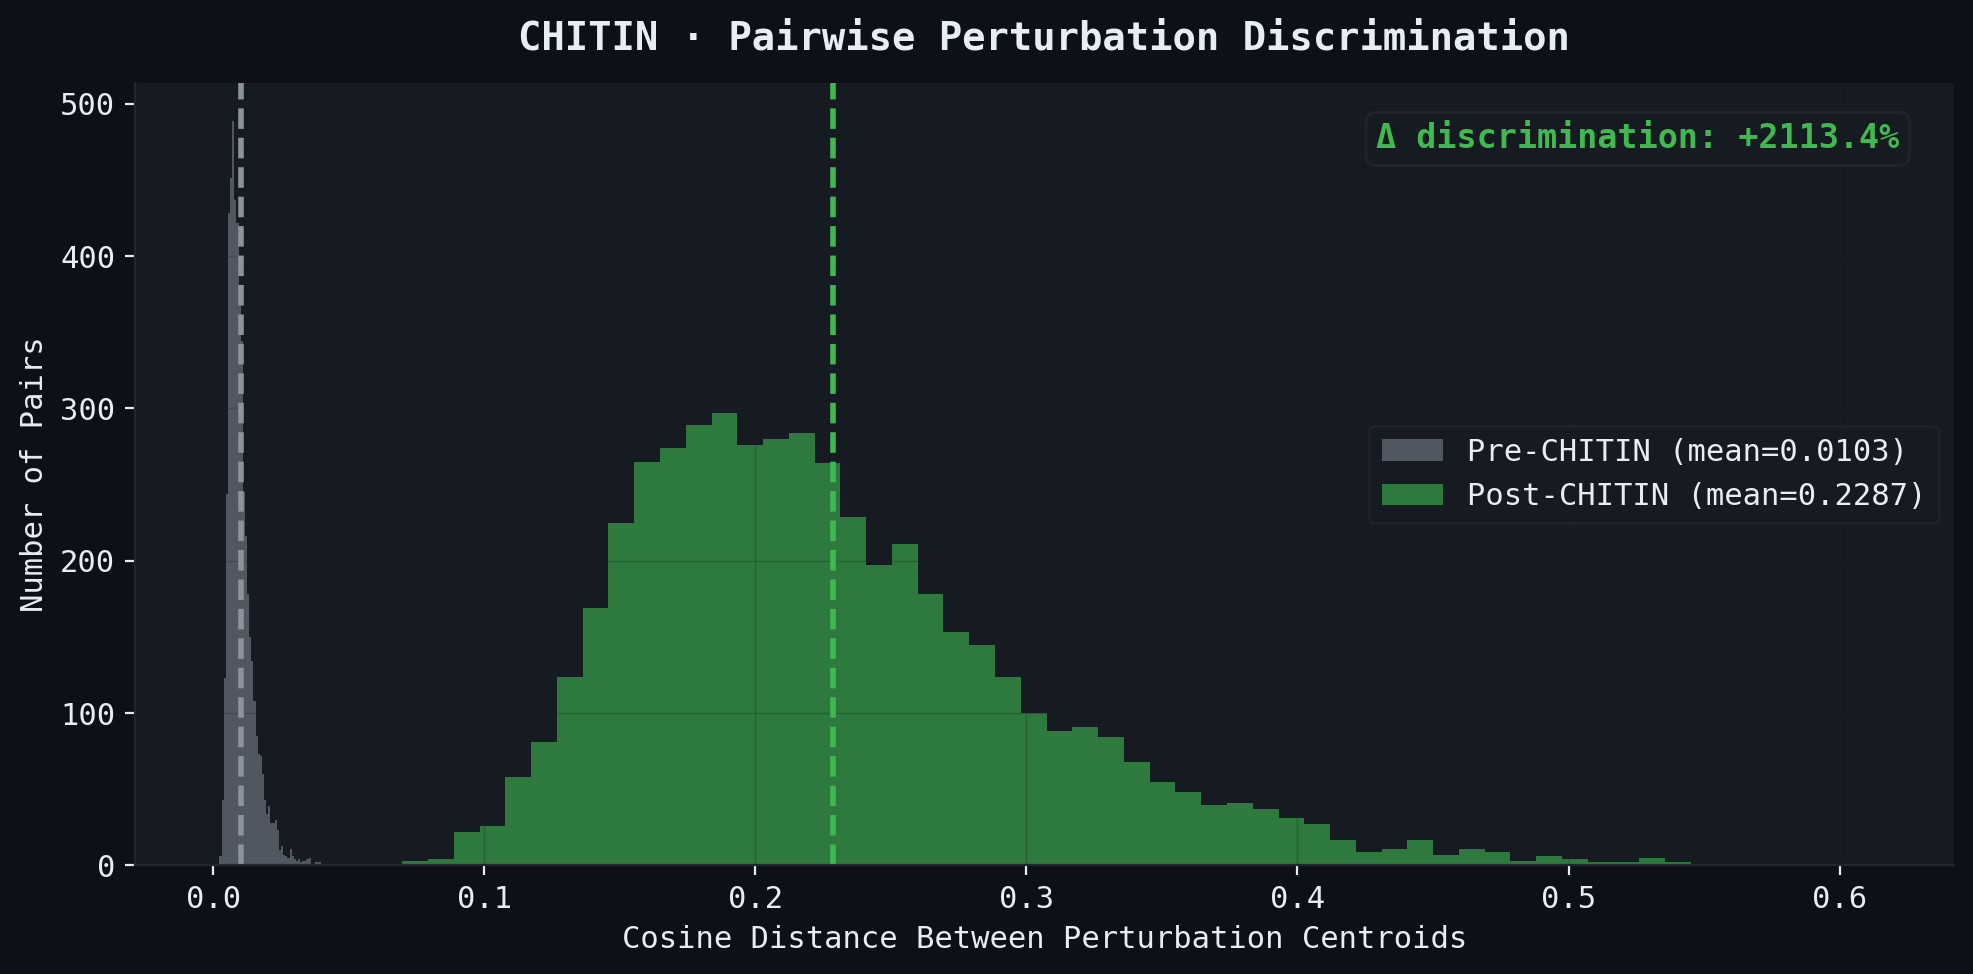

In [15]:
# ── Pairwise Perturbation Discrimination ──
dist_pre, dist_post = diag.compute_pairwise_discrimination(
    adata_train, adata_train_delta, cfg, logger)
cplt.plot_pairwise_discrimination(dist_pre, dist_post, cfg)

### Delta Magnitude Analysis

*Which perturbations have the strongest causal signals after CHITIN?*

In [16]:
# Delta magnitude statistics
delta_df, delta_norms = diag.compute_delta_magnitudes(
    adata_train_delta, cfg, logger)

11:40:21 │ INFO    │   Delta magnitudes: mean=43.9408, std=18.9119
11:40:21 │ INFO    │   Top 5 strongest perturbations:
11:40:21 │ INFO    │     TIMM50: |Δ|=63.7262 (n=5)
11:40:21 │ INFO    │     GMNN: |Δ|=61.6464 (n=5)
11:40:21 │ INFO    │     RRN3: |Δ|=58.6989 (n=5)
11:40:21 │ INFO    │     IMP4: |Δ|=57.9819 (n=8)
11:40:21 │ INFO    │     DMRT1: |Δ|=57.8679 (n=5)


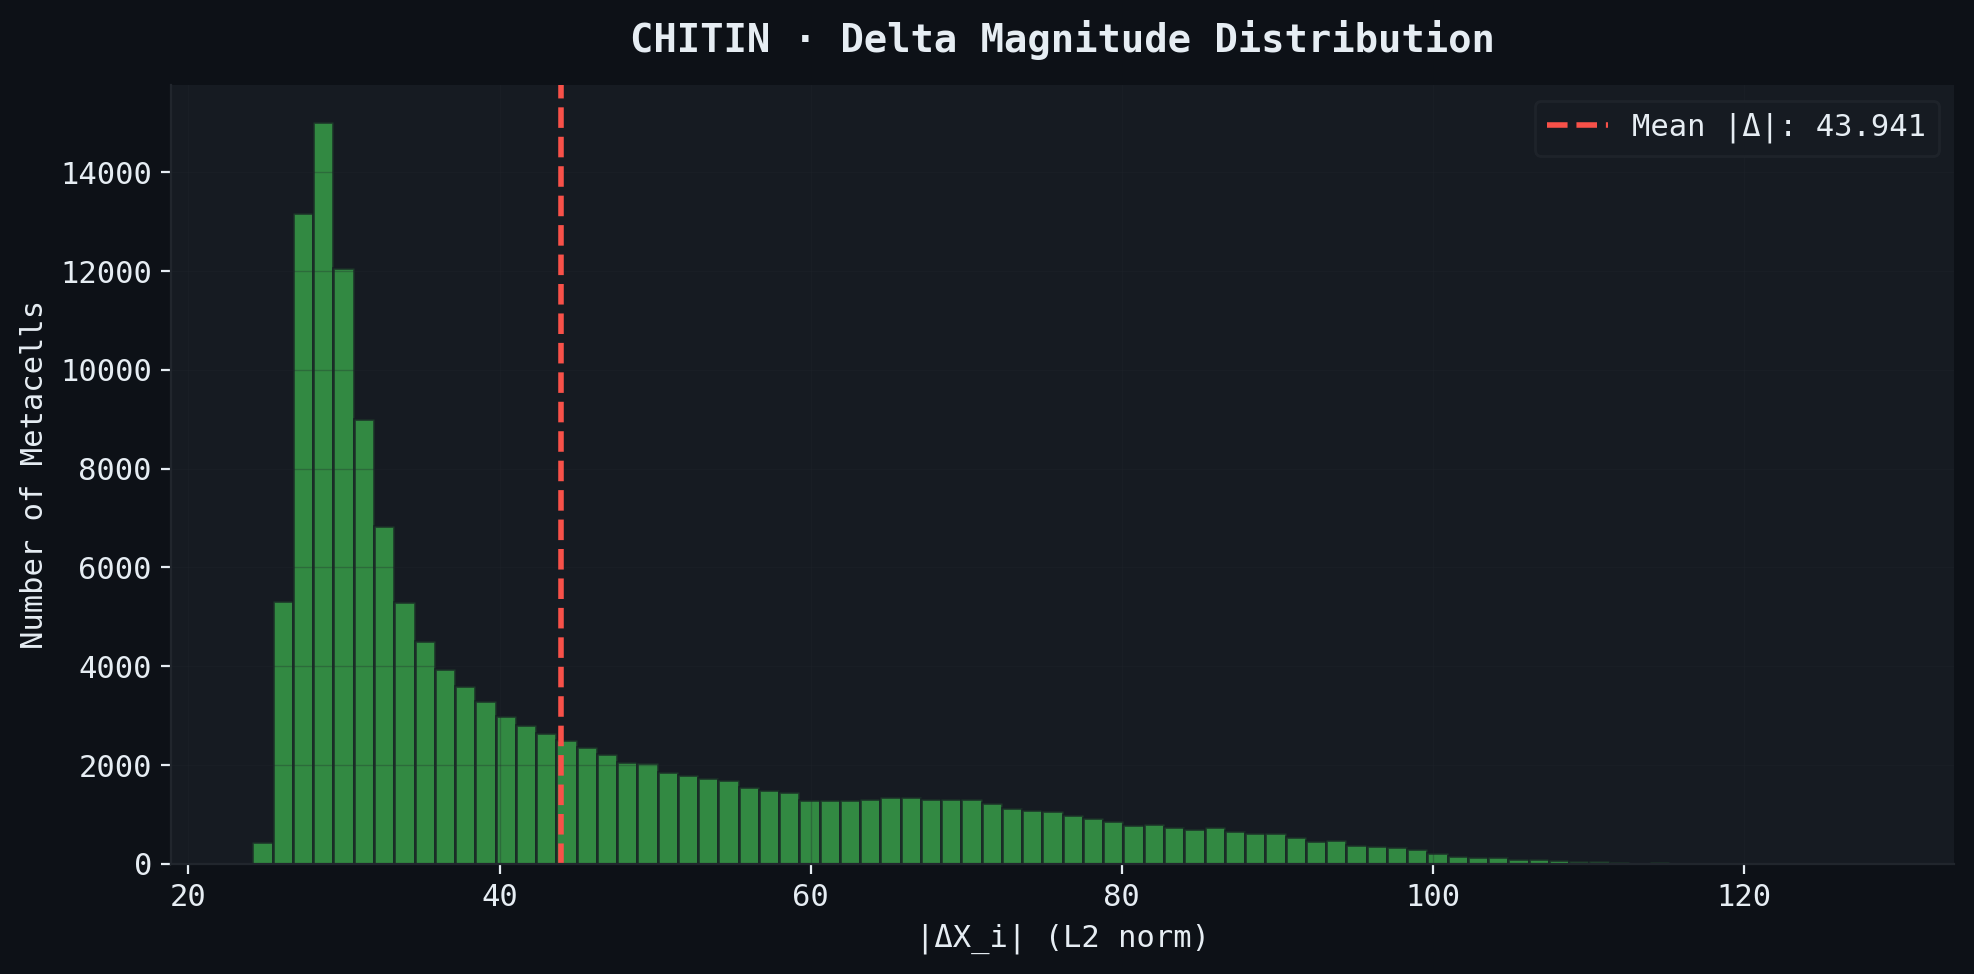

In [17]:
# Delta magnitude distribution
cplt.plot_delta_magnitude_distribution(delta_norms, cfg)

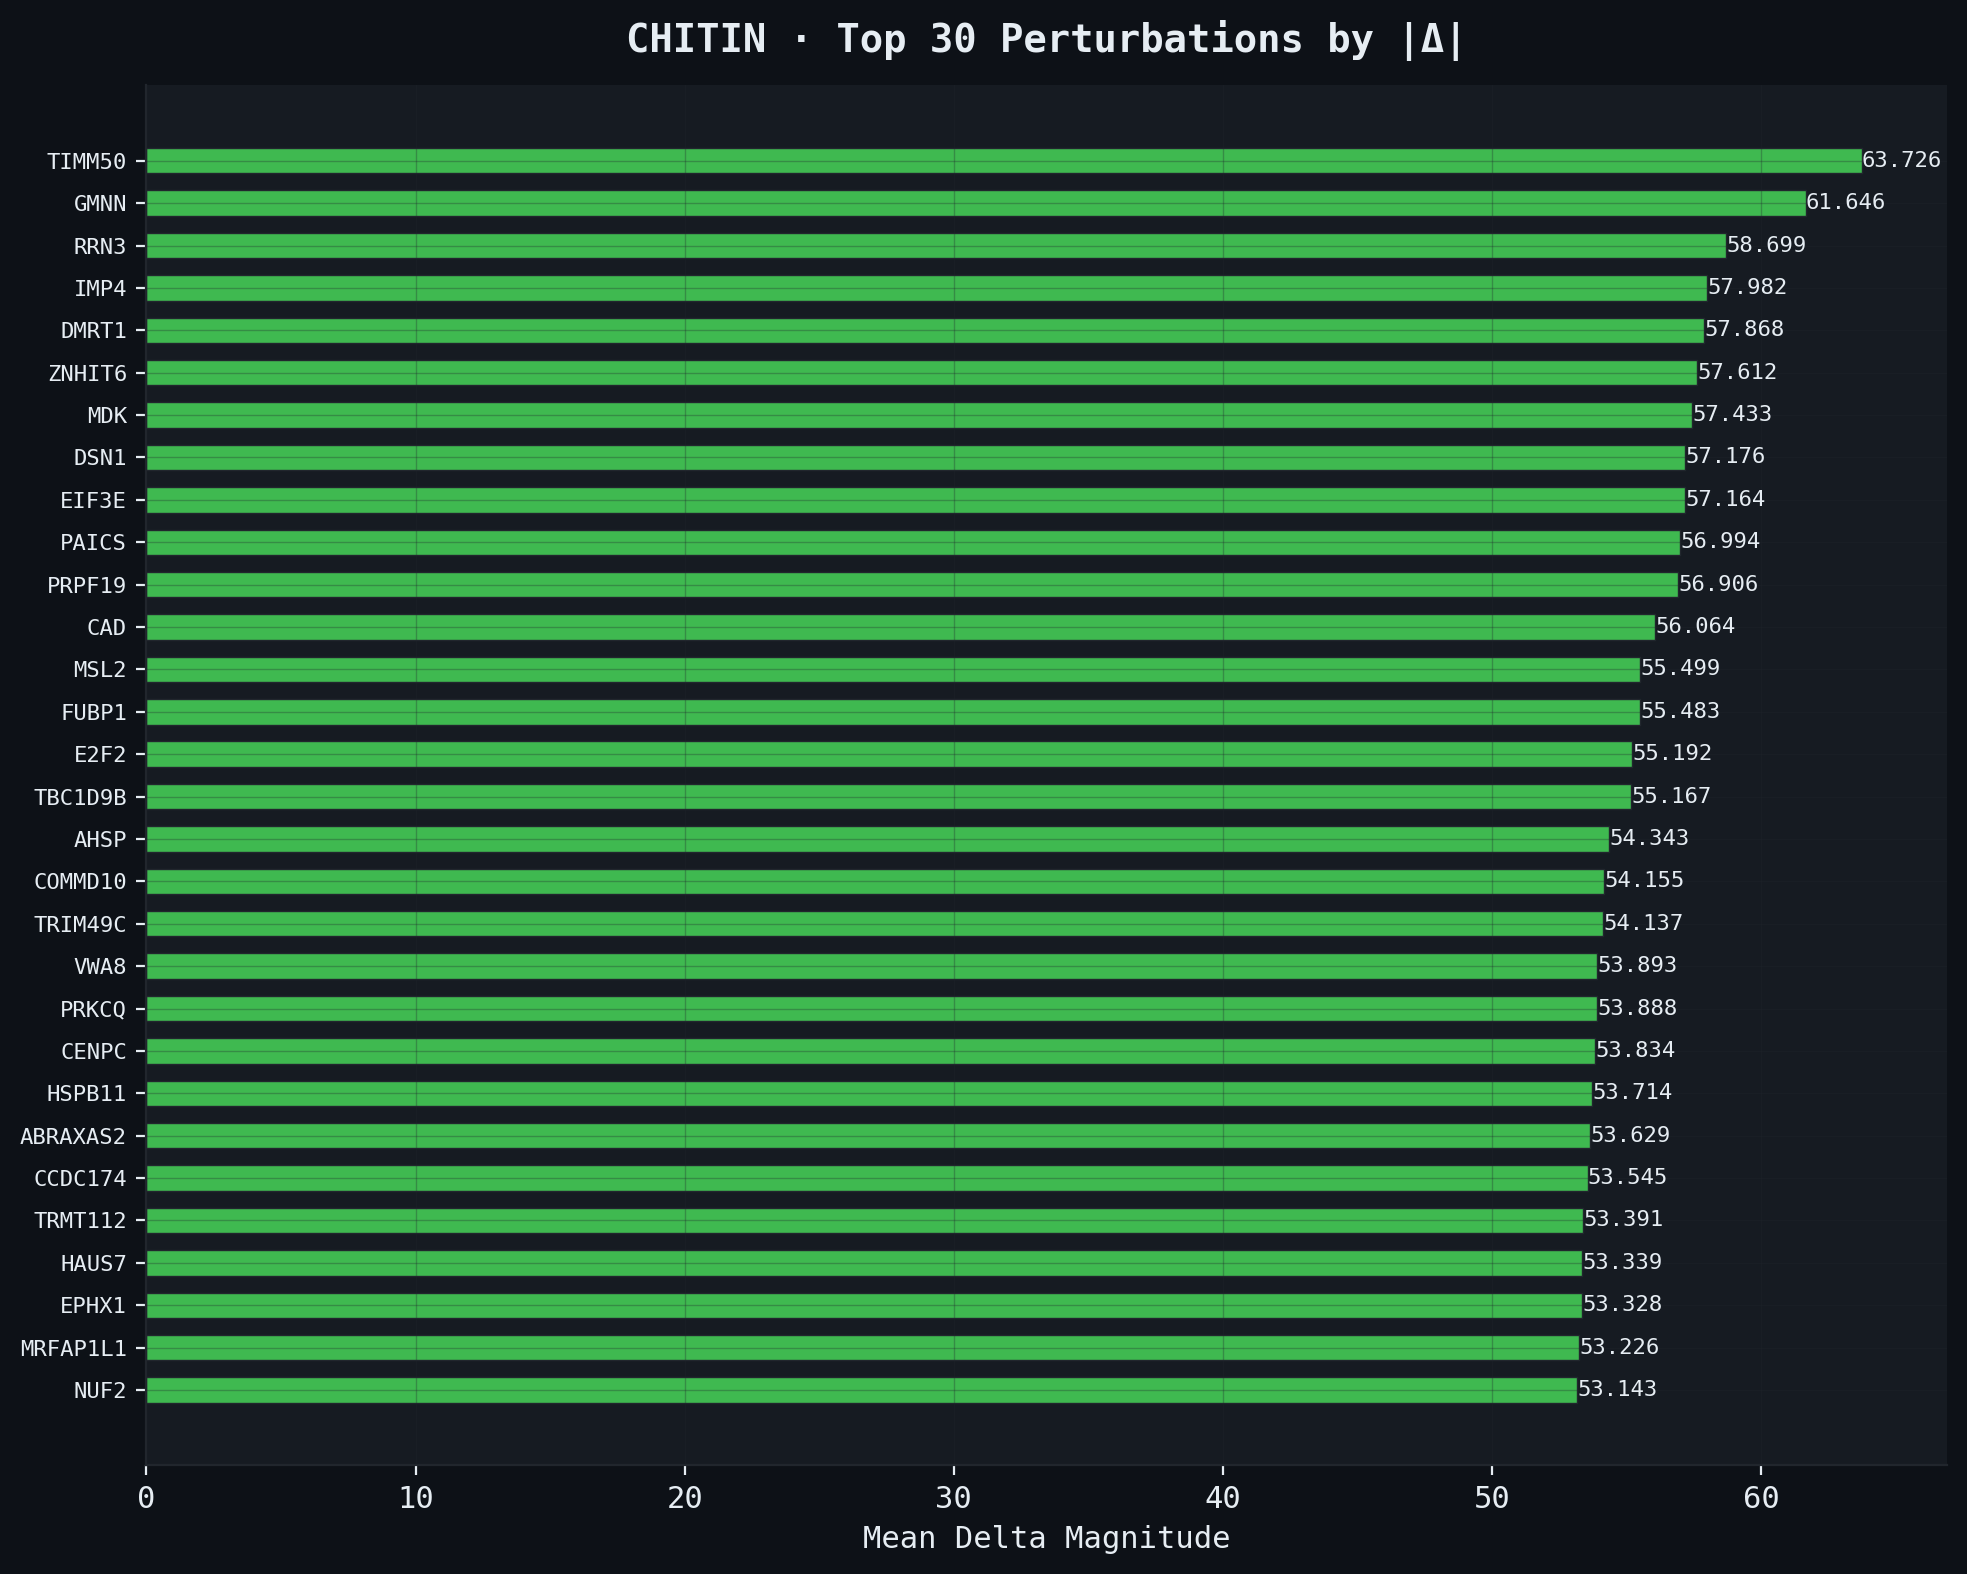

In [18]:
# Top perturbations by causal signal strength
cplt.plot_top_perturbation_deltas(delta_df, cfg, n_top=30)

---
## Transform Val & Test Splits

Apply CHITIN independently to val and test splits.  
Each split gets its own fresh PCA and KNN — no leakage.

In [19]:
# Val split
val_path = cfg['paths']['_input'] / cfg['paths']['val_file']
adata_val = sc.read_h5ad(val_path)
snapshot(adata_val, 'Val metacells loaded', logger)

# Project and transform using the TRAINING reference manifold
adata_val_delta = chitin_model.transform(adata_val, cfg, logger, label="Val")
del adata_val
force_gc(logger)

11:40:34 │ INFO    │   [Val metacells loaded] → 32,291 metacells  ×  5,000 genes  |  RAM: 14.4 GB
11:40:34 │ INFO    │ ════════════════════════════════════════════════════════════
11:40:34 │ INFO    │   CHITIN · Transforming [Val]
11:40:34 │ INFO    │ ════════════════════════════════════════════════════════════
11:40:34 │ INFO    │   [Val] Controls in this split: 7,483 | Perturbed: 24,808
11:40:34 │ INFO    │   Projecting into training PCA space...
11:40:35 │ INFO    │   [Val] KNN complete → 24,808 × 20 neighbors
11:40:37 │ INFO    │   [Post CHITIN [Val]] → 32,291 metacells  ×  5,000 genes  |  RAM: 17.8 GB
11:40:38 │ INFO    │   🗑️  GC collected 88935 objects  |  RAM: 15.5 GB


In [20]:
# Test split
test_path = cfg['paths']['_input'] / cfg['paths']['test_file']
adata_test = sc.read_h5ad(test_path)
snapshot(adata_test, 'Test metacells loaded', logger)

# Project and transform using the TRAINING reference manifold
adata_test_delta = chitin_model.transform(adata_test, cfg, logger, label="Test")
del adata_test
force_gc(logger)

11:40:38 │ INFO    │   [Test metacells loaded] → 17,868 metacells  ×  5,000 genes  |  RAM: 15.9 GB
11:40:38 │ INFO    │ ════════════════════════════════════════════════════════════
11:40:38 │ INFO    │   CHITIN · Transforming [Test]
11:40:38 │ INFO    │ ════════════════════════════════════════════════════════════
11:40:38 │ INFO    │   [Test] Controls in this split: 0 | Perturbed: 17,868
11:40:38 │ INFO    │   Projecting into training PCA space...
11:40:38 │ INFO    │   [Test] KNN complete → 17,868 × 20 neighbors
11:40:40 │ INFO    │   [Post CHITIN [Test]] → 17,868 metacells  ×  5,000 genes  |  RAM: 18.0 GB
11:40:40 │ INFO    │   🗑️  GC collected 13 objects  |  RAM: 16.6 GB


---
## Save CHITIN Outputs

Δ-transformed `.h5ad` files ready for GuanLab PSGRN.

In [22]:
output_dir = cfg['paths']['_output']
suffix = cfg['output']['suffix']
dataset = cfg['dataset']['name']

splits = {'train': adata_train_delta, 'val': adata_val_delta, 'test': adata_test_delta}

for key, ad in splits.items():
    fname = f"{dataset}_{key}{suffix}.h5ad"
    path = output_dir / fname
    ad.write_h5ad(path)
    logger.info(f"Saved {key} → {path}")
    print(f"  ✓ {key}: {ad.n_obs:,} metacells × {ad.n_vars:,} genes → {fname}")

print(f"\nAll CHITIN outputs saved to: {output_dir}")
log_memory(logger, 'pipeline complete')

11:41:20 │ INFO    │ Saved train → /scratch/patrick.sheehan/MYCELIUM/CHITIN/output/Replogle_2022_K562_GWPS_train_chitin.h5ad


  ✓ train: 150,293 metacells × 5,000 genes → Replogle_2022_K562_GWPS_train_chitin.h5ad


11:41:20 │ INFO    │ Saved val → /scratch/patrick.sheehan/MYCELIUM/CHITIN/output/Replogle_2022_K562_GWPS_val_chitin.h5ad


  ✓ val: 32,291 metacells × 5,000 genes → Replogle_2022_K562_GWPS_val_chitin.h5ad


11:41:20 │ INFO    │ Saved test → /scratch/patrick.sheehan/MYCELIUM/CHITIN/output/Replogle_2022_K562_GWPS_test_chitin.h5ad
11:41:20 │ INFO    │   💾 Memory (pipeline complete): 16.6 GB


  ✓ test: 17,868 metacells × 5,000 genes → Replogle_2022_K562_GWPS_test_chitin.h5ad

All CHITIN outputs saved to: /scratch/patrick.sheehan/MYCELIUM/CHITIN/output


---
## Summary

| Metric | Pre-CHITIN | Post-CHITIN |
|--------|------------|-------------|
| $\vec{V}$ (systematic variation) | computed above | computed above |
| Mean cosine (ctrl ref) | computed above | computed above |
| Mean cosine (pert ref) | computed above | computed above |

In [21]:
print("\n" + "═" * 60)
print("  CHITIN Pipeline Complete")
print("═" * 60)
print(f"  Rank-order disruption (mean Spearman ρ): {mean_rho:.4f}")
print(f"  Pairwise discrimination change: "
      f"{(dist_post.mean()-dist_pre.mean())/dist_pre.mean()*100:+.1f}%")
print(f"  Mean cosine (ctrl ref):")
print(f"    Pre-CHITIN:  {cos_ctrl_pre.mean():.4f}")
print(f"    Post-CHITIN: {cos_ctrl_post.mean():.4f}")
print(f"  k = {cfg['knn']['k']} neighbors")
print(f"  {cfg['knn']['n_pcs']} PCA components")
print(f"  Train: {adata_train_delta.n_obs:,} metacells")
print(f"  Val:   {adata_val_delta.n_obs:,} metacells")
print(f"  Test:  {adata_test_delta.n_obs:,} metacells")
print("═" * 60)
log_memory(logger, 'final')

11:41:08 │ INFO    │   💾 Memory (final): 16.6 GB



════════════════════════════════════════════════════════════
  CHITIN Pipeline Complete
════════════════════════════════════════════════════════════
  Rank-order disruption (mean Spearman ρ): 0.9267
  Pairwise discrimination change: +2113.4%
  Mean cosine (ctrl ref):
    Pre-CHITIN:  0.2437
    Post-CHITIN: 0.8778
  k = 20 neighbors
  50 PCA components
  Train: 150,293 metacells
  Val:   32,291 metacells
  Test:  17,868 metacells
════════════════════════════════════════════════════════════
